# 00. 全体像 — 時間を複素周波数の世界で代数にする

| 層 | セクション |
|---|---|
| — | 全体像・接続・読み方(オリエンテーション) |

> ラプラス変換を「変換表の暗記」ではなく「時間変化を $s$ 領域で代数的に扱う道具」として読む地図。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. ラプラス変換とは何か

ラプラス変換は、**時間 $t$ の関数 $f(t)$ を、複素周波数 $s$ の関数 $F(s)$ に移す道具**です。

$$ F(s) = \int_0^\infty f(t)\, e^{-st}\, dt $$

ここで $s = \sigma + i\omega$ は **複素周波数**。$\sigma$ は成長・減衰の速さ、$\omega$ は振動の速さを表します。
つまりラプラス変換は、世の中の「成長・減衰・振動」をひとつの言葉でまとめて扱うための変換です。

## 2. なぜラプラス変換を学ぶのか

時間領域では難しい操作が、$s$ 領域では簡単な代数になります。これが最大の動機です。

| 時間領域 $t$ | $s$ 領域 |
|---|---|
| 微分 $\frac{d}{dt}$ | $s$ の掛け算 |
| 畳み込み $f * g$ | 積 $F(s)G(s)$ |
| 微分方程式 (ODE) | 代数方程式 |
| 応答の形・安定性 | **極**(分母の根)の位置 |

「微分が掛け算になる」ので、微分方程式は **解く** ものから **整理する** ものに変わります。

## 3. 時間領域と s 領域(まず一枚の絵で)

本書で何度も出てくる中心的な対象は、**減衰しながら振動する波** $e^{\sigma t}\cos(\omega t)$ と、
それに対応する **$s$ 平面上の点(極)** $\sigma \pm i\omega$ の組です。下の図で両者を並べます。

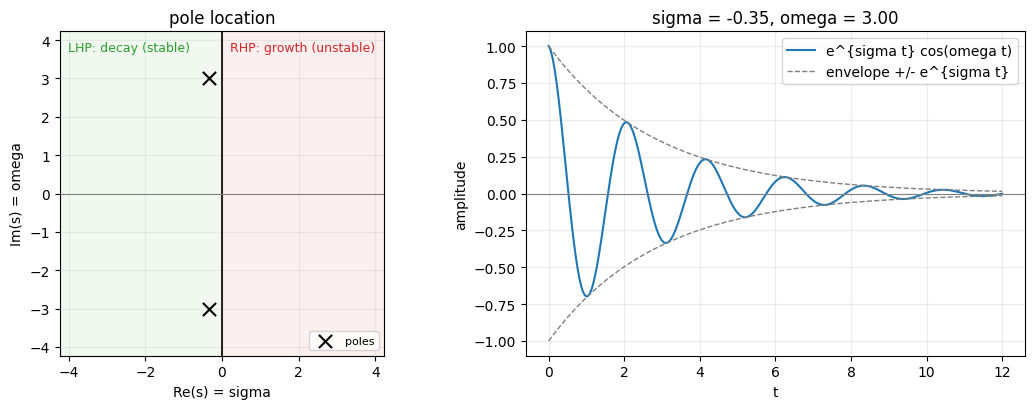

In [2]:
tt = np.linspace(0, 12, 500)
plotting.plot_pole_and_response(sigma=-0.35, omega=3.0, t=tt)
plt.tight_layout()

左の点(極)の **横位置 $\sigma$** が減衰の速さ、**縦位置 $\omega$** が振動の速さに、そのまま対応しています。
この「$s$ 平面の点 ↔ 時間の波」の対応こそ、ラプラス変換の幾何的な核心です(01・06 章で深掘り)。

## 4. フーリエ変換との違い

- フーリエ変換は $s = i\omega$(虚軸)だけを見る。つまり **純粋な振動** の世界。
- ラプラス変換は $s = \sigma + i\omega$ と **実部 $\sigma$ を足した**。だから成長・減衰する信号も扱える。
- ラプラス変換は **片側**($t\ge 0$)で定義し、**初期条件が自然に式へ入る**(02・04 章)。
- $\sigma$ のおかげで積分が収束しやすい(**収束域 ROC**、02 章)。

一言でいえば、フーリエが「振動の分解」なら、ラプラスは「成長・減衰・振動をまとめた分解」です。

## 5. 接続先 と この教材の読み方

ODE・制御・電気回路・信号処理・確率の各分野が、すべて $s$ 領域でつながります。
各章は次の流れで進みます。

> 現象 → 直感 → 可視化 → 数式 → Python 実験 → 応用 → 発展

そして各章を **Basic(最低限)/ Applied(Python と応用)/ Advanced(証明・発展)** の3層で読めます。
急ぐときは Basic だけ追えば筋が通るように作っています。

## 6. 章構成

| Notebook | 内容 |
|---|---|
| `00_overview` | 全体像・なぜ学ぶか・$s$ 領域・読み方(本章) |
| `01_exponential_decay_complex_frequency` | 指数・成長/減衰/振動・複素指数・$s$ 平面の直感 |
| `02_definition_basic_properties` | 定義・収束域・線形性・微分/積分/シフト・初期値 |
| `03_inverse_laplace_partial_fractions` | 逆変換・変換表・部分分数(重根/複素極)・SymPy |
| `04_solving_odes_with_laplace` | ODE を代数に・1階/2階・減衰/強制振動・ステップ |
| `05_convolution_impulse_response_transfer_functions` | 畳み込み定理・インパルス応答・伝達関数・LTI |
| `06_poles_zeros_stability` | 極と零点・$s$ 平面・極と応答・安定性 |
| `07_control_systems_and_circuits` | RC/RLC・ステップ/インパルス応答・フィードバック・Bode |
| `08_applications_probability_signals_finance` | 確率の MGF・割引現在価値・待ち行列入口 |

## 7. Python 環境の準備

共通関数は `src/laplace_book/` にまとまっています(`transforms` / `systems` / `circuits` /
`plotting` / `widgets` / `datasets`)。上の setup セルがインポート済みです。変換表をのぞいてみましょう。

In [3]:
# The core transform table (forward pairs). Inverse direction is chapter 03.
transforms.transform_table_df()

,f(t),F(s),note
0,$1$,$\frac{1}{s}$,unit step (t>=0)
1,$t$,$\frac{1}{s^{2}}$,ramp
2,$t^{n}$,$s^{- n - 1} n!$,power t^n
3,$e^{- a t}$,$\frac{1}{a + s}$,exponential decay
4,$\sin{\left(\omega t \right)}$,$\frac{\omega}{\omega^{2} + s^{2}}$,sine
5,$\cos{\left(\omega t \right)}$,$\frac{s}{\omega^{2} + s^{2}}$,cosine
6,$e^{- a t} \sin{\left(\omega t \right)}$,$\frac{\omega}{\omega^{2} + \left(a + s\right)...,damped sine
7,$e^{- a t} \cos{\left(\omega t \right)}$,$\frac{a + s}{\omega^{2} + \left(a + s\right)^...,damped cosine
8,$\delta(t)$,$1$,impulse


各 Notebook は上から順に実行できます(乱数は seed 固定)。では 01 章へ。